In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm.notebook import tqdm
import os


In [ ]:
#params
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_TRAIN = 20000
N_VAL = 2000
N_TEST = 10000
BATCH_SIZE = 2500
MAX_EPOCHS = 5000
LR_FIXE = 0.005

DOMAIN_LOW, DOMAIN_HIGH = -4.0, 4.0

In [ ]:
class HimmelblauNet4(nn.Module):
    def __init__(self, nb_neurones=16):
        super(HimmelblauNet4, self).__init__()
        self.fc1 = nn.Linear(2, nb_neurones)
        self.fc2 = nn.Linear(nb_neurones, nb_neurones)
        self.fc3 = nn.Linear(nb_neurones, nb_neurones)
        self.fc4 = nn.Linear(nb_neurones, nb_neurones)
        self.fc5 = nn.Linear(nb_neurones, 1)
        self.activation = nn.Tanh()

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.activation(self.fc3(x))
        x = self.activation(self.fc4(x))
        return self.fc5(x)

class EarlyStopping:
    def __init__(self, patience=200, min_delta=1e-6, path='best_model_classic_curve.pt'):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            torch.save(model.state_dict(), self.path)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.path)

In [ ]:
#data
def himmel(x, y):
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

def himmel_grad(x, y):
    df_dx = 4 * x * (x**2 + y - 11) + 2 * (x + y**2 - 7)
    df_dy = 2 * (x**2 + y - 11) + 4 * y * (x + y**2 - 7)
    return df_dx, df_dy

def generate_data(n_points):
    X_raw = torch.rand(n_points, 2) * (DOMAIN_HIGH - DOMAIN_LOW) + DOMAIN_LOW
    X_norm = X_raw / 4.0 #Normalisation

    y_raw_class = himmel(X_raw[:, 0], X_raw[:, 1]).unsqueeze(1)

    df_dx, df_dy = himmel_grad(X_raw[:, 0], X_raw[:, 1])
    y_raw_grad = torch.stack([df_dx, df_dy], dim=1)

    search_space = torch.linspace(DOMAIN_LOW, DOMAIN_HIGH, 1000)
    grid_x, grid_y = torch.meshgrid(search_space, search_space, indexing='xy')
    max_val_class = torch.max(himmel(grid_x, grid_y)).item()

    grad_x_grid, grad_y_grid = himmel_grad(grid_x, grid_y)
    max_val_grad = torch.max(torch.abs(torch.stack([grad_x_grid, grad_y_grid]))).item()

    y_norm_class = y_raw_class / max_val_class #Normalisation
    y_norm_grad = y_raw_grad / max_val_grad #Normalisation
    return X_norm.to(DEVICE), y_norm_class.to(DEVICE), y_norm_grad.to(DEVICE), max_val_class, max_val_grad

print(f"Génération de {N_TRAIN} Train, {N_VAL} Val, et {N_TEST} Test")
X_train, y_train_class, y_train_grad, MAX_CLASS, MAX_GRAD = generate_data(N_TRAIN)
X_val, y_val_class, y_val_grad, _, _ = generate_data(N_VAL)
X_test, y_test_class, y_test_grad, _, _ = generate_data(N_TEST)

train_loader = DataLoader(TensorDataset(X_train, y_train_class), batch_size=BATCH_SIZE, shuffle=True)
X_val_req = X_val.clone().detach().requires_grad_(True)

In [ ]:
#Boucle d'entrainement
model = HimmelblauNet4(nb_neurones=16).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR_FIXE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.8, patience=20, min_lr=1e-6)

early_stopping = EarlyStopping(patience=100, min_delta=1e-8)
mse_criterion = nn.MSELoss()
mae_criterion = nn.L1Loss()

history_train_loss = []
history_val_loss = []

print("Début de l'entraînement (Stratégie : Classic - Énergie uniquement)")

for epoch in tqdm(range(MAX_EPOCHS), desc="Epochs"):
    #train
    model.train()
    epoch_train_loss = 0.0

    for X_batch, y_class_batch in train_loader:
        optimizer.zero_grad()

        preds_energy = model(X_batch)
        loss = mse_criterion(preds_energy, y_class_batch)

        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    history_train_loss.append(avg_train_loss)

    #val
    model.eval()
    with torch.no_grad():
        preds_val = model(X_val)
        val_loss = mse_criterion(preds_val, y_val_class).item()

    history_val_loss.append(val_loss)

    scheduler.step(val_loss)
    early_stopping(val_loss, model)

    if early_stopping.early_stop:
        print(f"Early Stopping déclenché à l'epoch {epoch + 1}")
        break

#Final test
print("\nÉvaluation finale sur les 10 000 points de Test")

#best model load
model.load_state_dict(torch.load(early_stopping.path, weights_only=True))
model.eval()

#test
X_test_req = X_test.clone().detach().requires_grad_(True)

with torch.set_grad_enabled(True):
    preds_test_energy_norm = model(X_test_req)

    real_preds_energy = preds_test_energy_norm * MAX_CLASS
    real_targets_energy = y_test_class * MAX_CLASS
    test_mae_energy = mae_criterion(real_preds_energy, real_targets_energy).item()

    # Évaluation Forces (Auto-diff sur le modèle entraîné classiquement)
    grad_test = torch.autograd.grad(
        outputs=preds_test_energy_norm, inputs=X_test_req,
        grad_outputs=torch.ones_like(preds_test_energy_norm), create_graph=False
    )[0]
    real_grad_preds = grad_test * (MAX_CLASS / 4.0)
    real_grad_targets = y_test_grad * MAX_GRAD
    test_mae_force = mae_criterion(real_grad_preds, real_grad_targets).item()

    # MSE Normalisée pour le graphe (Énergie)
    test_mse_loss = mse_criterion(preds_test_energy_norm, y_test_class).item()

print(f"MAE Énergie finale  : {test_mae_energy:.4f}")
print(f"MAE Force finale    : {test_mae_force:.4f}")
print(f"Test Loss (MSE norm): {test_mse_loss:.6e}")

⚙️ Génération de 20000 Train, 2000 Val, et 10000 Test...
🚀 Début de l'entraînement (Stratégie : Classic - Énergie uniquement)


Epochs:   0%|          | 0/5000 [00:00<?, ?it/s]

⏹️ Early Stopping déclenché à l'epoch 3393 !

🧪 Évaluation finale sur les 10 000 points de Test...
📊 MAE Énergie finale  : 0.3633
📊 MAE Force finale    : 0.9524
📉 Test Loss (MSE norm): 2.690470e-06


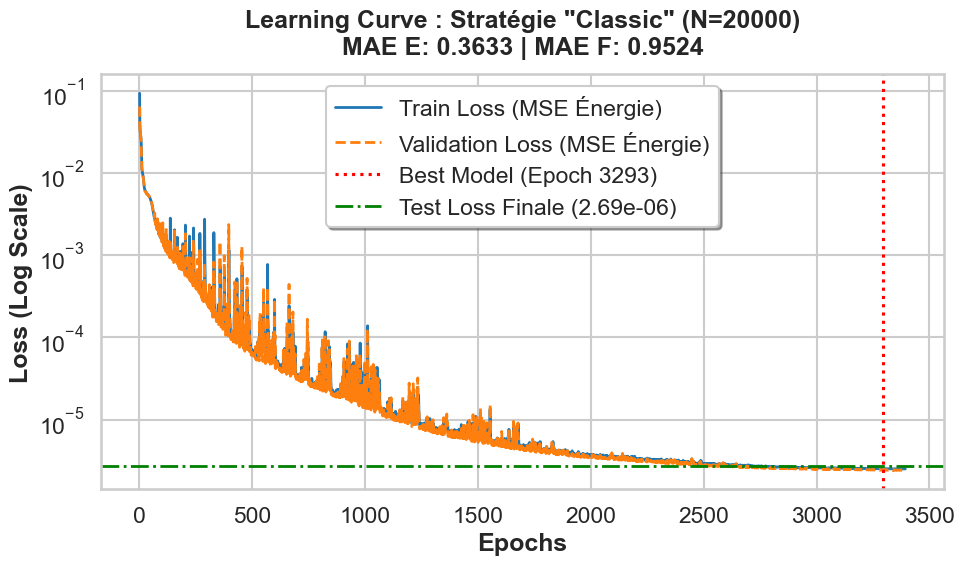

In [ ]:
#graph
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(10, 6))

epochs_range = range(1, len(history_train_loss) + 1)

plt.plot(epochs_range, history_train_loss, label='Train Loss (MSE Énergie)', color='#1f77b4', linewidth=2)
plt.plot(epochs_range, history_val_loss, label='Validation Loss (MSE Énergie)', color='#ff7f0e', linewidth=2, linestyle='--')

best_epoch = len(history_train_loss) - early_stopping.patience
if best_epoch > 0:
    plt.axvline(x=best_epoch, color='red', linestyle=':', label=f'Best Model (Epoch {best_epoch})')

plt.axhline(y=test_mse_loss, color='green', linestyle='-.', linewidth=2, label=f'Test Loss Finale ({test_mse_loss:.2e})')

plt.yscale('log')
plt.xlabel('Epochs', fontweight='bold')
plt.ylabel('Loss MSE normalised (Log Scale)', fontweight='bold')
plt.title(f'Learning Curve : Stratégie "Classic" (N={N_TRAIN})\nMAE E: {test_mae_energy:.4f} | MAE F: {test_mae_force:.4f}', fontweight='bold', pad=15)
plt.legend(frameon=True, shadow=True)
plt.tight_layout()

plt.show()